# **Customer Behaviour Analysis With Customer Lifetime Value**

## **Introduction**



### **GOAL**

Compute **Customer Lifetime Value (CLV)** refers to the total expected revenue a business can earn from a customer throughout their relationship. The longer a customer remains active and the more frequently they purchase, the higher their CLV.

A common way to estimate customer value over time is the **RFM model**, which considers:

- __Recency (R)__ : How recently the customer made a purchase.

- __Frequency (F)__ : How often the customer makes purchases.

- __Monetary (M)__ : How much the customer spends.

- __T (Tenure)__ : The duration between their first purchase and the end of the study period.


#### **Customer Personality Dataset Description:**

The Customer Personality Analysis dataset is a Kaggle dataset designed for customer segmentation, containing demographic details, spending habits, and product preferences of retail customers. It's widely used for clustering, profiling, predict campaign success, and marketing strategy optimization.


### **Feature Distribution:**

**1. Customer Information**
- ID – Unique identifier for each customer
- Year_Birth – Customer's birth year
- Education – Level of education
- Marital_Status – Marital status

**2. Financial Details**
- Income – Annual household income
- Kidhome – Number of children at home
- Teenhome – Number of teenagers at home

**3. Purchase Behavior**
- Recency – Days since last purchase
- MntWines – Amount spent on wine
- MntFruits – Amount spent on fruits
- MntMeatProducts – Amount spent on meat products
- MntFishProducts – Amount spent on fish products
- MntSweetProducts – Amount spent on sweets
- MntGoldProds – Amount spent on gold products

**4. Purchase Channels**
- NumDealsPurchases – Number of purchases made with discount
- NumWebPurchases – Purchases made online
- NumCatalogPurchases – Purchases via catalog
- NumStorePurchases – Purchases in-store
- NumWebVisitsMonth – Monthly website visits

**5. Campaign Response**
- AcceptedCmp1–AcceptedCmp5 – Acceptance of previous campaigns
- Response – Response to the last campaign (Target variable)

**6. Customer Engagement**
- Complain – Whether the customer complained
- Dt_Customer – Date of customer enrollment


**This dataset represents the customers profile and behaviour across multiple years, where each row corresponds to one customer. It includes demographic details, family composition, income, purchasing behaviour and product spending.**

### **1. Data Ingestion & Understanding**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown


In [2]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

    

In [3]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'raw')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)

0   marketing_campaign.csv


In [4]:
display_md("**Loading Raw Dataset...**")
try:
    customer_org = pd.read_csv(files[0], sep='\t')
    
    # standardize the column names
    customer_org.columns = customer_org.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    customer_data = customer_org.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'], format='%d-%m-%Y')
    display_md(f"**Dataset Shape : {customer_data.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_data.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")

**Loading Raw Dataset...**

**Dataset Shape : (2240, 29)**

**Number of duplicate rows in dataset : 0**

In [5]:
customer_data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [6]:
display_md(f"**Customer Information :**")
customer_data.info()

**Customer Information :**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

- `Education` & 'Marital_Status' are two categorical features.
- `Dt_Customer` only datetime feature.
- Other features are numbers.

In [7]:
## Column Formatting & Consistency
dtype_df = pd.DataFrame(
    index=customer_data.columns, columns=['dtype', 'nunique', 'unique']
)
dtype_df['dtype'] = customer_data.dtypes
dtype_df['nunique'] = customer_data.nunique()
dtype_df['unique'] = [customer_data[col].unique() for col in dtype_df.index]

display(dtype_df)

,dtype,nunique,unique
ID,int64,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177..."
Year_Birth,int64,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 198..."
Education,object,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
Marital_Status,object,8,"[Single, Together, Married, Divorced, Widow, A..."
Income,float64,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, ..."
Kidhome,int64,3,"[0, 1, 2]"
Teenhome,int64,3,"[0, 1, 2]"
Dt_Customer,datetime64[ns],663,"[2012-09-04 00:00:00, 2014-03-08 00:00:00, 201..."
Recency,int64,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 8..."
MntWines,int64,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6..."


## **2. EDA**

**2.1. Missing Values Analysis & Imputation**

In [8]:
miss_df = customer_data.stb.missing().query('percent > 0')
miss_df

,missing,total,percent
Income,24,2240,1.071429


- `Income` is only feature with missing values.

In [9]:
# drop NA values
customer_df = customer_data.dropna()

In [10]:
customer_df.shape

(2216, 29)

**2.2. Identify Outliers**

Statistics of Age:
    Skewness : 0.3522
    Kurtosis : 0.7331
Statistics of Income:
    Skewness : 0.2984
    Kurtosis : 0.4835


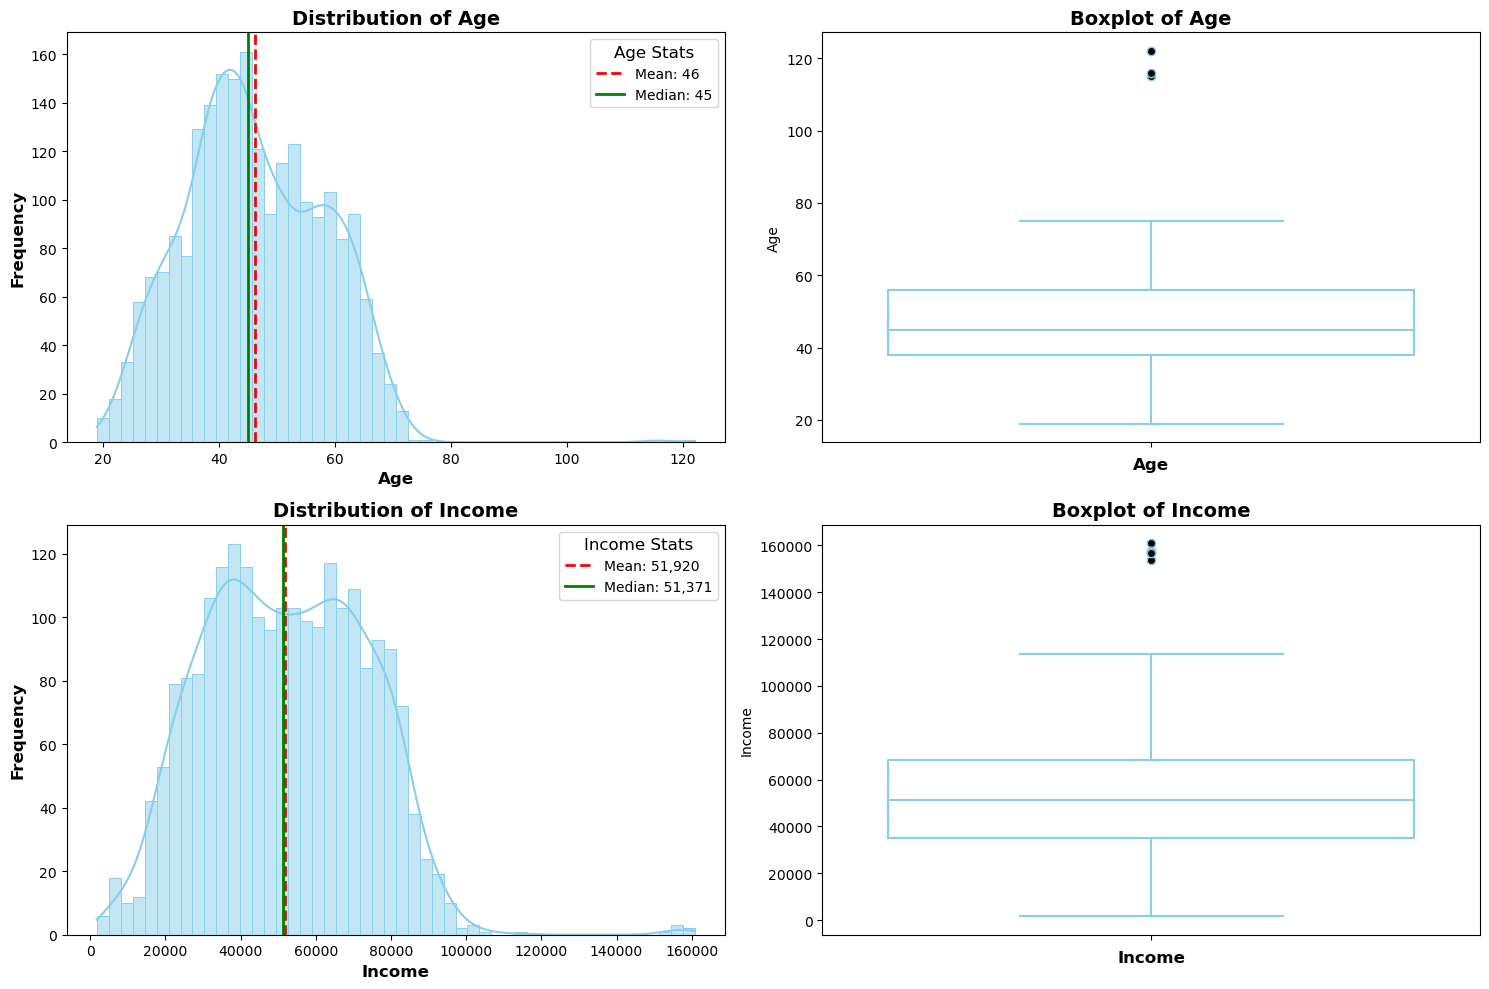

In [ ]:
# Check in float features
float_col = customer_df.select_dtypes(include=['float']).columns.tolist()


# Plot histogram with KDE
print()
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['Age', 'Income']
fig, axes = plt.subplots(len(cols), 2, figsize=(15, 5*len(cols)))

for i, col in enumerate(cols):
    y = customer_df[col]

    # Print stats
    print(f"""Statistics of {col}:
    Skewness : {y.skew():.4f}
    Kurtosis : {y.kurt():.4f}""") # kurtosis > 3 means heavy tails, more outliers than normal

    mean_val = y.mean()
    median_val = y.median()

    # Histogram
    sns.histplot(y, kde=True, bins=50, color='skyblue', ax=axes[i,0], edgecolor='skyblue')
    axes[i,0].axvline(mean_val, color="red", linestyle="--", linewidth=2, label=f"Mean: {mean_val:,.0f}")
    axes[i,0].axvline(median_val, color="green", linestyle="-", linewidth=2, label=f"Median: {median_val:,.0f}")
    axes[i,0].set_title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    axes[i,0].set_xlabel(col, fontsize=12, fontweight='bold')
    axes[i,0].set_ylabel("Frequency", fontsize=12, fontweight='bold')
    axes[i,0].legend(title=f"{col} Stats", title_fontsize=12)

    # Boxplot
    sns.boxplot(y=y, color='skyblue', fill=False,
                flierprops={'marker':'o','markerfacecolor':'k'}, ax=axes[i,1])
    axes[i,1].set_title(f"Boxplot of {col}", fontsize=14, fontweight='bold')
    axes[i,1].set_xlabel(col, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [12]:
# income outliers dataset
customer_df.query("Income > 161000")

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
617,1503,1976,PhD,Together,162397.0,1,1,2013-06-03,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,2013-06-02,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0


- There are several customers who earn more than 160,000 and some of them even more than 600,000. They are clearly outliers in the data.

In [13]:
# Removing outliers by setting a cap on income
customer_df = customer_df.query('Income < 161000')
customer_df.shape

(2214, 29)

__2.3. Categorical Features__

In [14]:
categorical_cols = customer_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['Education', 'Marital_Status']

In [15]:
# Check education if need some correction
print(f"Education Original Distribution : {customer_data['Education'].value_counts(normalize=True)}")

# Segmenting eduction level in 4 groups
customer_df['Education'] = customer_df['Education'].replace({
    'PhD':'PhD',
    'Master':'PostGraduation',
    '2n Cycle':'PostGraduation',
    'Graduation':'Graduation',
    'Basic':'UnderGraduation'
})
print("="*50)
print(f"Education Altered Distribution : {customer_df['Education'].value_counts(normalize=True)}")

Education Original Distribution : Education
Graduation    0.503125
PhD           0.216964
Master        0.165179
2n Cycle      0.090625
Basic         0.024107
Name: proportion, dtype: float64
Education Altered Distribution : Education
Graduation         0.503613
PostGraduation     0.255194
PhD                0.216802
UnderGraduation    0.024390
Name: proportion, dtype: float64


- Half of the customers are university graduates. There are more customers with a Master's degree than customers with a PhD, only few customers have high school degree.

In [16]:
# Check marital status if need some correction
print(f"Marital Status Original Distribution : {customer_data['Marital_Status'].value_counts(normalize=True)}")

# Segmenting marital status level in 2 groups
customer_df['Marital_Status'] = customer_df['Marital_Status'].replace({
    'Married':'Partner',
    'Together':'Partner',
    'Divorced':'Single',
    'Widow' : 'Single',
    'Alone' : 'Single',
    'Absurd': 'Single',
    'YOLO' : 'Single'
})
print("="*50)
print(f"Marital Status Altered Distribution : {customer_df['Marital_Status'].value_counts(normalize=True)}")


Marital Status Original Distribution : Marital_Status
Married     0.385714
Together    0.258929
Single      0.214286
Divorced    0.103571
Widow       0.034375
Alone       0.001339
Absurd      0.000893
YOLO        0.000893
Name: proportion, dtype: float64
Marital Status Altered Distribution : Marital_Status
Partner    0.644986
Single     0.355014
Name: proportion, dtype: float64


- 2/3 of customers live with a partner while about 1/3 are still single.

**2.4. Feature Engineering**

In [17]:
customer_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

**2.4.1. Customer's Age**

To calculate each customer's age, we use their year of birth. Since customer registrations occurred between 2012 and 2014, we assume the dataset was collected in January 2015, and ages are computed relative to that date.

In [18]:
customer_df['Age'] = 2015 - customer_df['Year_Birth']

**2.4.2.1. Is_parent**

To determine whether a customer is a parent, we add the values of Kidhome and Teenhome. If the sum is greater than zero, the customer is classified as a parent (1); otherwise, they are not (0).

In [19]:
customer_df['Is_parent'] = np.where((customer_df['Kidhome'] + customer_df['Teenhome']) > 0, 1, 0)

In [20]:
customer_df['Is_parent'].value_counts(normalize=True)

Is_parent
1    0.714092
0    0.285908
Name: proportion, dtype: float64

- A majority of customers (71%) are parents, whereas 29% fall into the non-parent category.

**2.4.2.2. Total Children at Home**

Merging Kidhome and Teenhome into a single feature representing the total number of children living at home.

In [27]:
customer_df['Children'] = customer_df['Kidhome'] + customer_df['Teenhome']

**2.4.3. Date Components Extraction**

In [49]:
import datetime as dt
customer_df['Day'] = customer_df['Dt_Customer'].dt.day
customer_df['Month'] = customer_df['Dt_Customer'].dt.month
customer_df['Quarter'] = customer_df['Dt_Customer'].dt.quarter
customer_df['Year'] = customer_df['Dt_Customer'].dt.year
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Date,Month,Quarter,Year,Monetry,Frequency,Children,Tenure,Day
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,4,9,3,2012,1617,22,0,28,4
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,8,3,1,2014,27,4,2,9,8
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,21,8,3,2013,776,20,0,16,21
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,10,2,1,2014,53,6,1,10,10
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,19,1,1,2014,422,14,1,11,19


**2.4.4. Monetry**

Aggregate the expenses across all product categories to compute each customer's total expenditure.

In [25]:
customer_df['Monetry'] = (
    customer_df['MntFishProducts'] + customer_df['MntGoldProds'] +
    customer_df['MntFruits'] + customer_df['MntMeatProducts'] +
    customer_df['MntSweetProducts'] + customer_df['MntWines']
)


**2.4.5. Frequency**

Use features like `NumWebPurchases`, `NumCatalogPurchases`, and `NumStorePurchases` to compute how often a customer shops across different channels.

In [26]:
customer_df['Frequency'] = (
    customer_df['NumCatalogPurchases'] +
    customer_df['NumStorePurchases'] + 
    customer_df['NumWebPurchases']
)

**2.4.6. Tenure**

Computing how many months each customer has been connected to the company based on their registration date.

In [39]:
reference_date = pd.to_datetime('2015-01-01')

# Calculate tenure in months
customer_df['Tenure'] = ((reference_date - customer_df['Dt_Customer'])/ pd.Timedelta(days=30)).astype(int)

In [ ]:
customer_df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Is_parent', 'Date', 'Month', 'Quarter', 'Year'],
      dtype='object')

In [28]:
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Date,Month,Quarter,Year,Monetry,Frequency,Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,4,9,3,2012,1617,22,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,8,3,1,2014,27,4,2
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,21,8,3,2013,776,20,0
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,10,2,1,2014,53,6,1
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,19,1,1,2014,422,14,1


**2.5. Data Visualization**

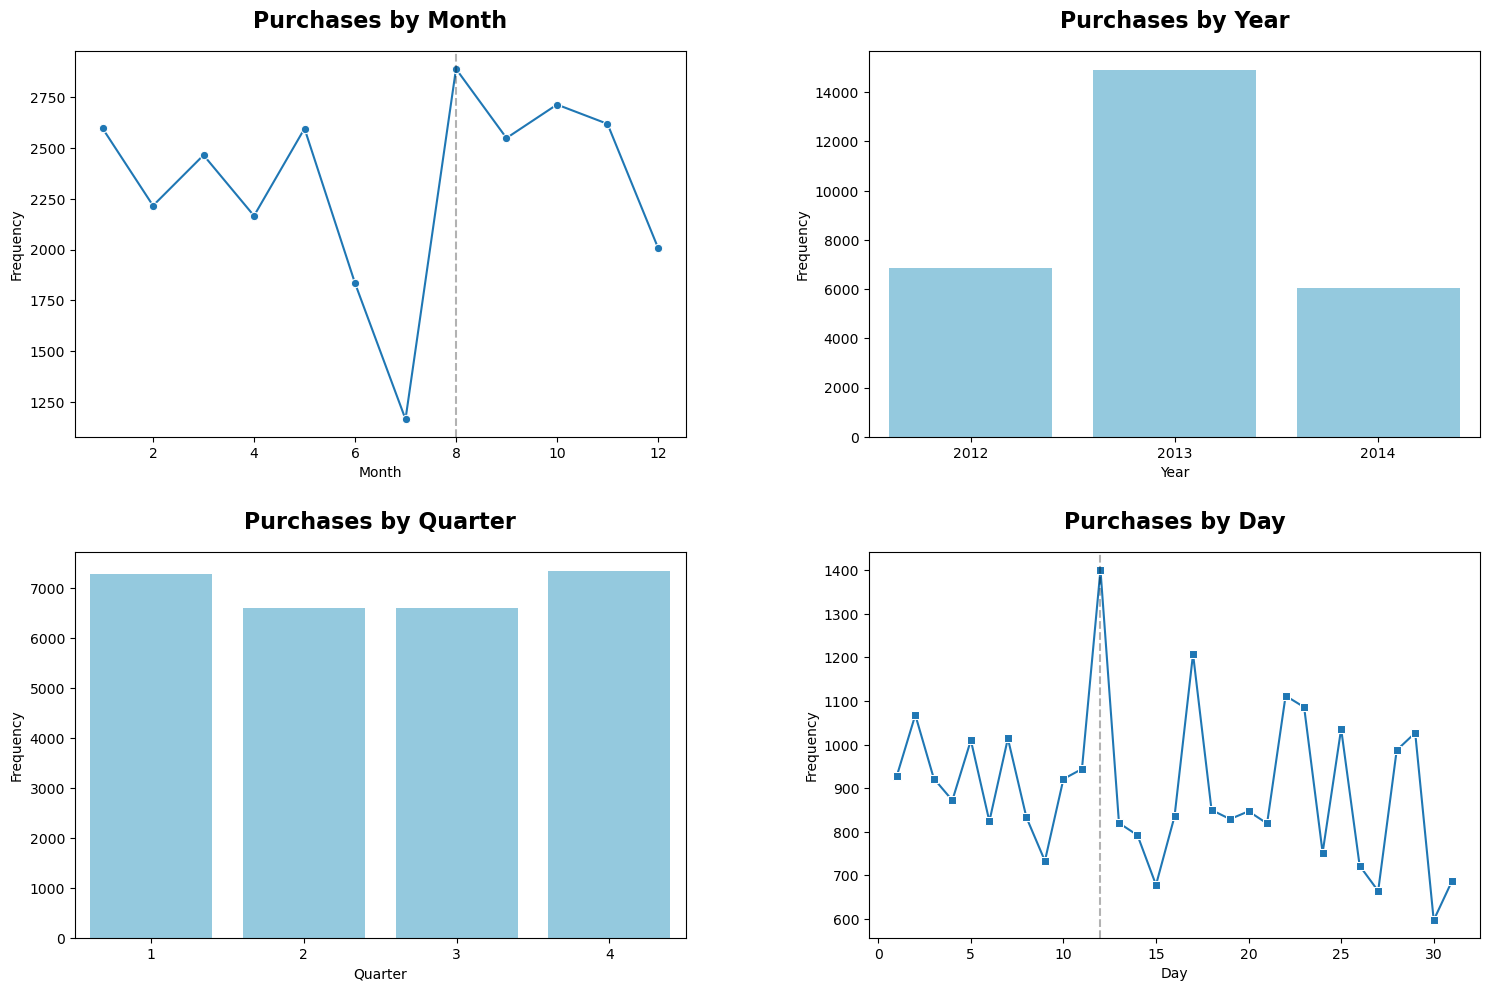

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Purchases by Month
sns.lineplot(
    data=customer_df.groupby('Month', as_index=False)['Frequency'].sum(),
    x='Month', y='Frequency', marker='o', ax=axes[0,0]
)
axes[0,0].set_title("Purchases by Month",fontsize=16, fontweight='bold', y=1.04)
axes[0,0].axvline(x=8, color="k", linestyle="--", alpha=0.3)

# Purchases by Year
sns.barplot(
    data=customer_df.groupby('Year', as_index=False)['Frequency'].sum(),
    x='Year', y='Frequency', ax=axes[0,1], color="skyblue"
)
axes[0,1].set_title("Purchases by Year", fontsize=16, fontweight='bold', y=1.04)

# Purchases by Quarter
sns.barplot(
    data=customer_df.groupby('Quarter', as_index=False)['Frequency'].sum(),
    x='Quarter', y='Frequency', ax=axes[1,0], color="skyblue"
)
axes[1,0].set_title("Purchases by Quarter", fontsize=16, fontweight='bold', y=1.04)

# Purchases by Day
sns.lineplot(
    data=customer_df.groupby('Day', as_index=False)['Frequency'].sum(),
    x='Day', y='Frequency', marker='s', ax=axes[1,1]
)
axes[1,1].set_title("Purchases by Day", fontsize=16, fontweight='bold', y=1.04)
axes[1,1].axvline(x=12, color="k", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()
